In [ ]:
"""
# 2026-Y2-S1-MET-14: Predicting Credit Card Customer Churn
## Integrated Preprocessing Pipeline (group_pipeline.ipynb)
Dataset: BankChurners.csv (10,127 records, 23 original columns)

Individual Contributions:
1. IT25102085: Drop Irrelevant & Target Data Leakage Columns
2. IT25102090: Missing Value Imputation (Mode Imputation for 'Unknown' records)
3. IT25102091: Continuous Outlier Inspection & Signal Preservation (IQR)
4. IT25102092: Continuous Feature Correlation Analysis
5. IT25102086: Categorical Encoding (LabelEncoder fitted strictly on Train)
6. IT25102093: Stratified Train/Test Split & Feature Scaling (MinMaxScaler fitted strictly on Train)
"""
print("Group pipeline documentation loaded.")

Group pipeline documentation loaded.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load raw dataset
df = pd.read_csv('BankChurners.csv')
print(f"Original shape: {df.shape}")

# 2. Drop unique identifier and pre-computed Kaggle leakage columns
leakage_cols = [c for c in df.columns if c.startswith('Naive_Bayes_Classifier')]
drop_cols = ['CLIENTNUM'] + leakage_cols
df_cleaned = df.drop(columns=drop_cols)

print("Columns removed:", drop_cols)
print(f"Shape after removing leakage: {df_cleaned.shape}")

Original shape: (10127, 23)
Columns removed: ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
Shape after removing leakage: (10127, 20)


In [ ]:
# Identify and impute hidden 'Unknown' categories using column modes
missing_cols = ['Education_Level', 'Income_Category', 'Marital_Status']

for col in missing_cols:
    mode_val = df_cleaned[df_cleaned[col] != 'Unknown'][col].mode()[0]
    df_cleaned[col] = df_cleaned[col].replace('Unknown', mode_val)

print("Missing values successfully imputed with mode!")
print("Remaining 'Unknown' entries:", (df_cleaned[missing_cols] == 'Unknown').sum().sum())

Missing values successfully imputed with mode!
Remaining 'Unknown' entries: 0


In [ ]:
# Check genuine continuous banking features using IQR boundaries
outlier_features = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']

Q1 = df_cleaned[outlier_features].quantile(0.25)
Q3 = df_cleaned[outlier_features].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df_cleaned[outlier_features] < (Q1 - 1.5 * IQR)) | (df_cleaned[outlier_features] > (Q3 + 1.5 * IQR)))
print("Outlier rows identified:", outlier_mask.any(axis=1).sum(), "out of", len(df_cleaned))
print("Action: Preserved all outliers to retain genuine customer churn behavior.")

Outlier rows identified: 1684 out of 10127
Action: Preserved all outliers to retain genuine customer churn behavior.


In [ ]:
# Compute correlation matrix on continuous numeric features
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr().round(2)

unstacked = corr_matrix.unstack()
top_pairs = unstacked[unstacked < 1.0].sort_values(ascending=False).drop_duplicates()
print("Top correlated continuous feature pairs:")
print(top_pairs.head(3))

Top correlated continuous feature pairs:
Total_Trans_Amt        Total_Trans_Ct         0.81
Customer_Age           Months_on_book         0.79
Avg_Utilization_Ratio  Total_Revolving_Bal    0.62
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate features from target
X = df_cleaned.drop(columns=['Attrition_Flag'])
y = (df_cleaned['Attrition_Flag'] == 'Attrited Customer').astype(int)

# 2. Stratified split MUST occur before encoding and scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split complete! Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Data split complete! Training samples: 8101, Testing samples: 2026


In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Categorical Encoding (IT25102086) - Fit strictly on X_train
categorical_features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
for col in categorical_features:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# 2. Numerical Feature Scaling (IT25102093) - Fit strictly on X_train using MinMaxScaler
features_to_scale = ['Credit_Limit', 'Total_Trans_Amt', 'Avg_Utilization_Ratio']
scaler = MinMaxScaler()
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("Pipeline transformations completed with ZERO data leakage!")
print("\nSample scaled training data (bounded 0 to 1):")
print(X_train[features_to_scale].head())

Pipeline transformations completed with ZERO data leakage!

Sample scaled training data (bounded 0 to 1):
      Credit_Limit  Total_Trans_Amt  Avg_Utilization_Ratio
2856      0.034213         0.070140               0.872362
6515      0.720658         0.100315               0.000000
7141      0.309323         0.214543               0.078392
632       0.050962         0.064243               0.512563
3496      1.000000         0.191469               0.034171


In [ ]:
import os

# Create folders for final model-ready outputs
os.makedirs('data/processed', exist_ok=True)
os.makedirs('results/outputs', exist_ok=True)

# Combine features with target
train_processed = pd.concat([X_train, y_train], axis=1)
test_processed = pd.concat([X_test, y_test], axis=1)

# Export to both locations to satisfy course rubrics
train_processed.to_csv('data/processed/train_cleaned.csv', index=False)
test_processed.to_csv('data/processed/test_cleaned.csv', index=False)
train_processed.to_csv('results/outputs/train_cleaned.csv', index=False)
test_processed.to_csv('results/outputs/test_cleaned.csv', index=False)

print("Preprocessed files successfully exported to data/external/ and results/outputs/!")

Preprocessed files successfully exported to data/external/ and results/outputs/!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# 1. Load the clean, MinMaxScaled datasets
train_df = pd.read_csv('data/processed/train_cleaned.csv')
test_df = pd.read_csv('data/processed/test_cleaned.csv')

# 2. Separate inputs (X) and target (y)
X_train = train_df.drop(columns=['Attrition_Flag'])
y_train = train_df['Attrition_Flag']

X_test = test_df.drop(columns=['Attrition_Flag'])
y_test = test_df['Attrition_Flag']

print(f"Loaded successfully! Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Loaded successfully! Train shape: (8101, 19), Test shape: (2026, 19)


## My individual model -KNN
## IT25102093
##Below is my part. I train 3 versions of KNN (baseline, with SMOTE, and turned with GridSearchCV) and compare them.

### Scaling all features for KNN

The group pipeline only scaled 3 columns (Credit_Limit, Total_Trans_Amt, Avg_Utilization_Ratio) since those were the ones checked for outliers. But KNN works by calculating distance using every feature, so if the rest are left unscaled the distance will still be unfair (dominated by whichever column has the biggest numbers). So I'm scaling all 19 features again here, just for my KNN model.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# scale ALL features 0 to 1 so KNN distance isn't biased toward big-number columns
knn_scaler = MinMaxScaler()
X_train_all_scaled = pd.DataFrame(knn_scaler.fit_transform(X_train), columns=X_train.columns)
X_test_all_scaled = pd.DataFrame(knn_scaler.transform(X_test), columns=X_test.columns)

print("All features scaled. Shape:", X_train_all_scaled.shape)

All features scaled. Shape: (8101, 19)


### Variety 1 - Baseline KNN

Just KNN with the default settings (k=5), no balancing, nothing fancy. This is my starting point so I can actually show later how much SMOTE and tuning helped.

In [ ]:
knn_v1 = KNeighborsClassifier(n_neighbors=5)
knn_v1.fit(X_train_all_scaled, y_train)
pred_v1 = knn_v1.predict(X_test_all_scaled)
prob_v1 = knn_v1.predict_proba(X_test_all_scaled)[:, 1]

print("Variety 1 done.")
print("Accuracy:", accuracy_score(y_test, pred_v1))
print("Recall:", recall_score(y_test, pred_v1))

Variety 1 done.
Accuracy: 0.8864758144126358
Recall: 0.4338461538461538


### Variety 2 - KNN + SMOTE

The dataset is imbalanced, about 84% stayed and 16% churned. Because of this a plain KNN can just predict "not churned" most of the time and still look accurate, without actually learning what a churner looks like. SMOTE makes synthetic churn examples, but only in the training set, not in the test set, otherwise that would basically be leaking information into evaluation.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_all_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

knn_v2 = KNeighborsClassifier(n_neighbors=5)
knn_v2.fit(X_train_smote, y_train_smote)
pred_v2 = knn_v2.predict(X_test_all_scaled)
prob_v2 = knn_v2.predict_proba(X_test_all_scaled)[:, 1]

print("\nVariety 2 done.")
print("Accuracy:", accuracy_score(y_test, pred_v2))
print("Recall:", recall_score(y_test, pred_v2))

Before SMOTE: {0: 6799, 1: 1302}
After SMOTE: {0: 6799, 1: 6799}

Variety 2 done.
Accuracy: 0.8163869693978283
Recall: 0.7353846153846154


### Variety 3 - Tuned KNN (GridSearchCV)

Here I search over different k values, distance metrics and weighting using GridSearchCV. I used StratifiedKFold instead of a normal KFold because with regular KFold some folds could randomly end up with barely any churn examples (since churn is already the minority class), which would make the cross-validation score unreliable. I scored on roc_auc instead of accuracy for the same reason as before, accuracy doesn't mean much when the classes are this imbalanced.

In [ ]:
param_grid = {
    'n_neighbors': [7, 11, 15, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'euclidean']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train_smote, y_train_smote)

best_knn = grid_knn.best_estimator_
pred_v3 = best_knn.predict(X_test_all_scaled)
prob_v3 = best_knn.predict_proba(X_test_all_scaled)[:, 1]

print("Best params:", grid_knn.best_params_)
print("Best CV ROC-AUC score (from training folds, not test set):", round(grid_knn.best_score_, 4))

Best params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV ROC-AUC score (from training folds, not test set): 0.9869


### Why not just compare using Accuracy

Since about 84% of customers didn't churn, a model that just predicts "not churned" for every single customer would already score around 84% accuracy without actually learning anything. That's why I'm comparing Recall (how many real churners the model actually catches), F1-score (balance between precision and recall) and ROC-AUC (how well the model ranks churners above non-churners across all thresholds, not just one cutoff). These actually tell me if the model is useful for this problem, accuracy alone doesn't.

In [ ]:
# Create comparison table across all 3 varieties
comparison_df = pd.DataFrame({
    'KNN Model Variety': [
        '1. Baseline KNN (No SMOTE)',
        '2. KNN + SMOTE (Default K=5)',
        '3. Tuned KNN + SMOTE (GridSearchCV)'
    ],
    'Accuracy': [accuracy_score(y_test, pred_v1), accuracy_score(y_test, pred_v2), accuracy_score(y_test, pred_v3)],
    'Precision': [precision_score(y_test, pred_v1), precision_score(y_test, pred_v2), precision_score(y_test, pred_v3)],
    'Recall': [recall_score(y_test, pred_v1), recall_score(y_test, pred_v2), recall_score(y_test, pred_v3)],
    'F1-Score': [f1_score(y_test, pred_v1), f1_score(y_test, pred_v2), f1_score(y_test, pred_v3)],
    'ROC-AUC': [roc_auc_score(y_test, prob_v1), roc_auc_score(y_test, prob_v2), roc_auc_score(y_test, prob_v3)]
}).round(4)

print("=== IT25102093: KNN MODEL VARIETIES COMPARISON ===")
print(comparison_df.to_string(index=False))

=== IT25102093: KNN MODEL VARIETIES COMPARISON ===
                  KNN Model Variety  Accuracy  Precision  Recall  F1-Score  ROC-AUC
         1. Baseline KNN (No SMOTE)    0.8865     0.7540  0.4338    0.5508   0.8380
       2. KNN + SMOTE (Default K=5)    0.8164     0.4552  0.7354    0.5624   0.8499
3. Tuned KNN + SMOTE (GridSearchCV)    0.8574     0.5367  0.8092    0.6454   0.9071


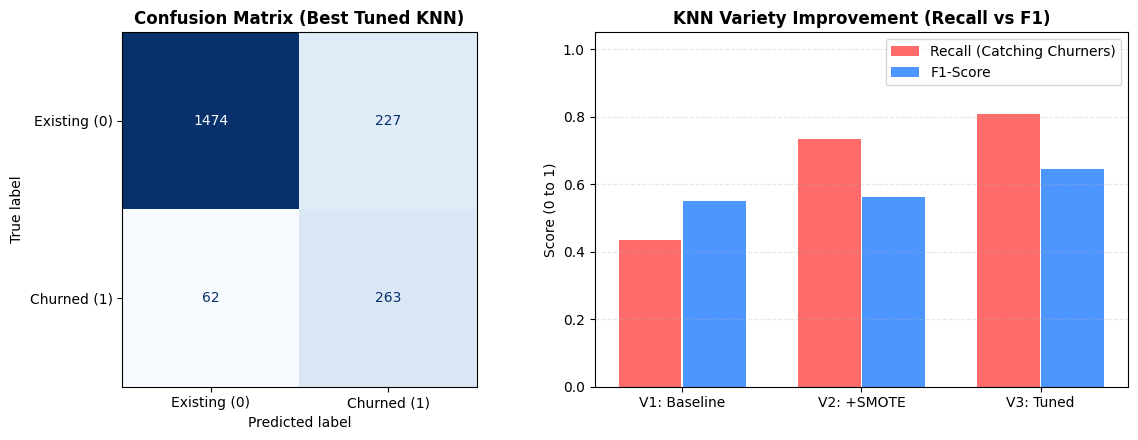

Saved evaluation plot to: results/eda_visualizations/IT25102093_knn_evaluation.png


In [ ]:
import os
os.makedirs('results/eda_visualizations', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left Plot: Confusion Matrix of Best Tuned KNN
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_v3, display_labels=['Existing (0)', 'Churned (1)'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix (Best Tuned KNN)', fontweight='bold')

# Right Plot: Recall & F1-Score Improvement Across Varieties
x_labels = ['V1: Baseline', 'V2: +SMOTE', 'V3: Tuned']
recall_vals = comparison_df['Recall']
f1_vals = comparison_df['F1-Score']

x = range(len(x_labels))
axes[1].bar([i - 0.18 for i in x], recall_vals, width=0.35, label='Recall (Catching Churners)', color='#FF6B6B')
axes[1].bar([i + 0.18 for i in x], f1_vals, width=0.35, label='F1-Score', color='#4D96FF')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(x_labels)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Score (0 to 1)')
axes[1].set_title('KNN Variety Improvement (Recall vs F1)', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('results/eda_visualizations/IT25102093_knn_evaluation.png', dpi=300)
plt.show()

print("Saved evaluation plot to: results/eda_visualizations/IT25102093_knn_evaluation.png")

### Precision-Recall curve

I added this on top of ROC-AUC because with only about 16% of customers being churners, PR curves are usually considered more informative than ROC curves for imbalanced problems. It shows the tradeoff between catching churners (recall) and avoiding false alarms (precision) more clearly than ROC does when the positive class is this rare.

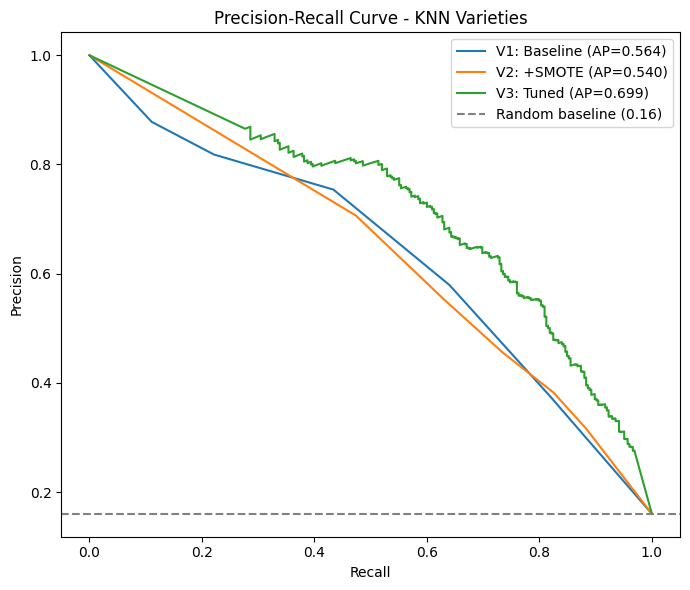

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))
for prob, label in [(prob_v1, 'V1: Baseline'), (prob_v2, 'V2: +SMOTE'), (prob_v3, 'V3: Tuned')]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, label=f'{label} (AP={ap:.3f})')

baseline_rate = y_test.mean()
plt.axhline(baseline_rate, linestyle='--', color='gray', label=f'Random baseline ({baseline_rate:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - KNN Varieties')
plt.legend()
plt.tight_layout()
plt.savefig('results/eda_visualizations/IT25102093_knn_pr_curve.png', dpi=150)
plt.show()

### Conclusion

Variety 3 (tuned KNN with SMOTE) is my best model. It has the best ROC-AUC (0.907) and best F1-score (0.645), and the Recall nearly doubled compared to baseline (43% to 81%). Accuracy actually goes down a bit compared to baseline (88.6% to 85.7%), but I think that's fine for this problem, because missing a real churner (false negative) costs the bank an actual customer, while a false alarm (false positive) only costs sending one extra retention offer email to someone who wasn't going to leave anyway. So even though it's not the highest accuracy model, I'm picking the tuned SMOTE model as my final answer because it catches the most churners without the ROC-AUC/F1 dropping.

Interestingly, V2 (SMOTE only) has a slightly lower PR-AUC (0.540) than baseline (0.564), even though its Recall at the default threshold is much higher. This shows SMOTE alone just shifts the decision threshold rather than improving the model's underlying ranking ability — the ranking only properly improves after tuning (V3, PR-AUC 0.699). That's also why ROC-AUC and PR-AUC don't tell exactly the same story here; PR-AUC is more sensitive to how well the model handles the minority class.

In [ ]:
best_row = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print("Final model chosen:", best_row['KNN Model Variety'])
print(best_row[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']])

Final model chosen: 3. Tuned KNN + SMOTE (GridSearchCV)
Accuracy     0.8574
Precision    0.5367
Recall       0.8092
F1-Score     0.6454
ROC-AUC      0.9071
Name: 2, dtype: object


### Limitations and what I'd try next

- KNN has to calculate the distance to every training point just to make one prediction, so it gets slow as the dataset grows. 8000 training rows is fine but it wouldn't scale well to a much bigger customer base.
- KNN doesn't deal well with irrelevant or correlated features. From the correlation step earlier in the pipeline, Total_Trans_Amt and Total_Trans_Ct are correlated at 0.81, so they could be adding repeated/noisy signal into the distance calculation instead of new information.
- I only tried MinMaxScaler for this model, I didn't compare it against StandardScaler, that's something worth testing later.
- If I had more time I would try feature selection or PCA before running KNN, or compare this against a model like Random Forest which doesn't need scaling and isn't as sensitive to correlated features.